# <center>Category 2: Descriptive Analysis</center>

### 1. What is the average resting heart rate, and how frequently does it exceed 100 bpm (tachycardia)?

##### **Reason:** This question helps identify the typical resting heart rate of patients and how often it exceeds 100 bpm (tachycardia). Heart rate is an important indicator of physical stress and autonomic nervous system activity. In type 1 diabetes, tachycardia may indicate Diabetic Cardiovascular Autonomic Neuropathy (DCAN), a condition where high blood sugar damages the nerves controlling the heart. Frequent elevated heart rates, especially during low glucose events, may also suggest hypoglycemia associated autonomic responses (HAAF). Analyzing tachycardia frequency helps assess whether a patient’s cardiovascular system is frequently under stress.

*** Average Resting Heart Rate per Patient ***
patient_id
HUPA0001P    76.56
HUPA0002P    61.12
HUPA0003P    72.25
HUPA0004P    75.20
HUPA0005P    82.61
HUPA0006P    60.03
HUPA0007P    64.26
HUPA0009P    78.47
HUPA0010P    74.26
HUPA0011P    63.73
HUPA0014P    76.75
HUPA0015P    61.96
HUPA0016P    79.95
HUPA0017P    75.74
HUPA0018P    71.94
HUPA0019P    64.35
HUPA0020P    71.37
HUPA0021P    68.07
HUPA0022P    60.13
HUPA0023P    64.80
HUPA0024P    61.47
HUPA0025P    75.25
HUPA0026P    73.19
HUPA0027P    72.81
HUPA0028P    72.06
Name: heart_rate, dtype: float64

Overall Average Resting HR: 70.33 bpm

***Tachycardia Frequency per Patient (HR > 100 bpm) ***
            total_readings  tachycardia_readings  tachycardia_percentage
patient_id                                                              
HUPA0016P             3835                  1207                   31.47
HUPA0017P             3599                   491                   13.64
HUPA0014P             3829                   4

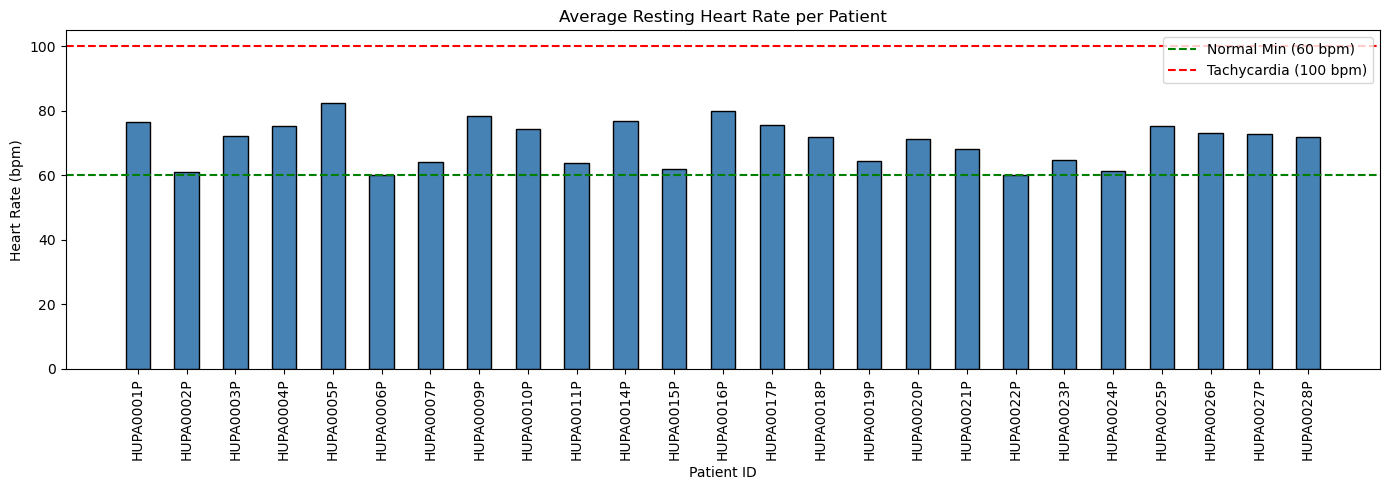

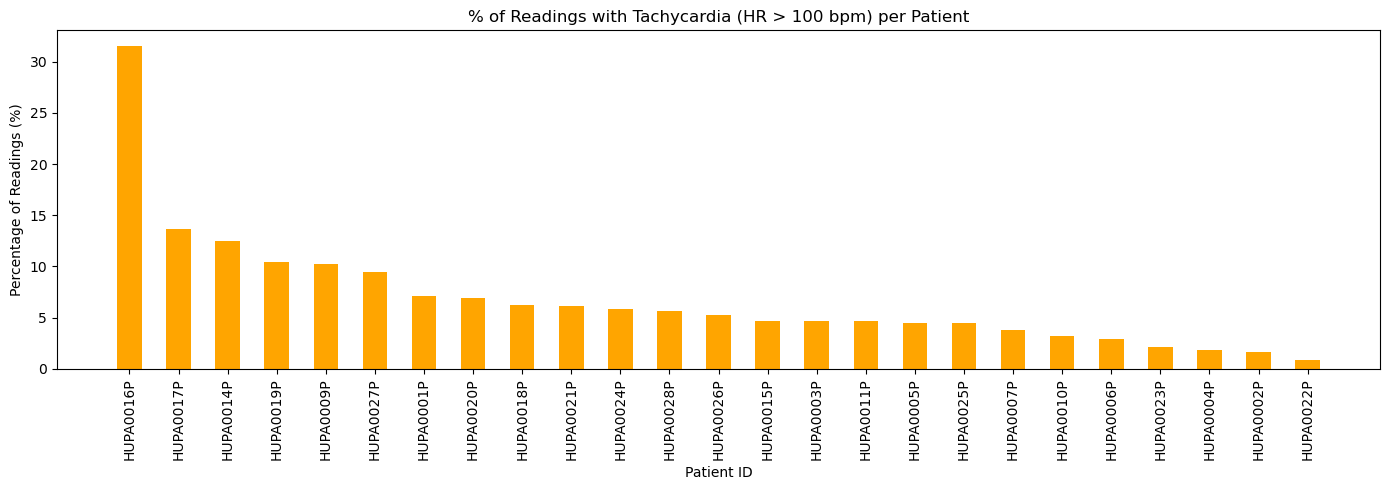

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Step 1 - Average resting heart rate per patient
# Resting = no physical activity (steps == 0)
resting_hr = df_all[df_all['steps'] == 0].groupby('patient_id')['heart_rate'].mean().round(2)

print("*** Average Resting Heart Rate per Patient ***")
print(resting_hr)
print(f"\nOverall Average Resting HR: {resting_hr.mean().round(2)} bpm")

# Step 2 - Tachycardia frequency per patient (heart rate > 100 bpm)
total_readings = df_all.groupby('patient_id')['heart_rate'].count()
tachycardia_readings = df_all[df_all['heart_rate'] > 100].groupby('patient_id')['heart_rate'].count()

tachycardia_summary = pd.DataFrame({
    'total_readings'          : total_readings,
    'tachycardia_readings'    : tachycardia_readings,
    'tachycardia_percentage'  : ((tachycardia_readings / total_readings) * 100).round(2)
}).fillna(0).sort_values('tachycardia_percentage', ascending=False)

print("\n***Tachycardia Frequency per Patient (HR > 100 bpm) ***")
print(tachycardia_summary)
print(f"\nPatient with highest tachycardia: "
      f"{tachycardia_summary['tachycardia_percentage'].idxmax()} "
      f"({tachycardia_summary['tachycardia_percentage'].max()}%)")

# Step 3 - Visualisation

# Plot 1 - Average resting heart rate per patient
x1 = resting_hr.index  # patient IDs
y1 = resting_hr.values  # average resting heart rate

plt.figure(figsize=(14, 5))
plt.bar(x1, y1, width=0.5, color='steelblue', edgecolor='black')
plt.axhline(y=60,  color='green', linestyle='--', linewidth=1.5, label='Normal Min (60 bpm)')
plt.axhline(y=100, color='red',   linestyle='--', linewidth=1.5, label='Tachycardia (100 bpm)')
plt.title('Average Resting Heart Rate per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Heart Rate (bpm)')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 - Tachycardia Percentage per Patient

x2 = tachycardia_summary.index           # patient IDs
y2 = tachycardia_summary['tachycardia_percentage']  # tachycardia %

plt.figure(figsize=(14, 5))
plt.bar(x2, y2, width=0.5, color='orange')
plt.title('% of Readings with Tachycardia (HR > 100 bpm) per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Percentage of Readings (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: Patient HUPA0016P had the highest tachycardia frequency at 31.47% followed by HUPA0017P </green>**